<h2>1. Introdução</h2>
Este projeto foi motivado pelo interesse em investigar padrões e mitos populares sobre a indústria cinematográfica, utilizando dados históricos do IMDB combinados com metadados enriquecidos via APIs do TMDB e OMDB. Através da coleta e cruzamento desses dados, buscamos testar hipóteses recorrentes sobre duração, gênero, idioma, orçamento/lucratividade e recepção crítica vs. popular.

<h3>1.1 Objetivo Geral</h3>
<ul><li>Investigar tendências e mitos populares sobre cinema a partir de dados históricos de duração, gênero, idioma, orçamento, receita e avaliação crítica vs. de público.</li></ul>

<h3>1.2 Objetivos Específicos</h3>
<ul>
<li>Comparar a duração de filmes de franquia contra filmes isolados</li>
<li>Analisar a evolução histórica do gênero Romance em termos de volume de produção e popularidade</li>
<li>Verificar a evolução da predominância de filmes em língua inglesa ao longo do tempo</li>
<li>Investigar a relação entre orçamento de produção e retorno financeiro/lucratividade</li>
<li>Comparar a divergência entre nota de crítica e nota de público entre diferentes gêneros</li>
</ul>

<h3>1.3 Perguntas a Serem Respondidas</h3>
<ol>
<li>Franquias de cinema realmente exigem mais tempo do público do que filmes originais? (Murilo)</li>
<li>O gênero Romance está morrendo? (Gabriel)</li>
<li>O domínio de filmes em língua inglesa está diminuindo? (Icaro)</li>
<li>Filmes baratos podem ser mais lucrativos que filmes caros? (Gabriel)</li>
<li>A divergência entre crítica e público é maior em algum gênero específico? (Kawane)</li>
</ol>

<h3>1.4 Bibliotecas utilizadas:</h3>
As bibliotecas utilizadas estão contidas no arquivo requirements.txt no diretório do presente trabalho.
>pip install -r requirements.txt

<h2>2. Dados Utilizados</h2>

Os dados utilizados correspondem a filmes registrados na base pública do IMDB, filtrados para conter apenas títulos com no mínimo 10.000 avaliações de usuários, garantindo relevância estatística mínima por filme. A base inicial foi posteriormente enriquecida com metadados obtidos através das APIs do TMDB (The Movie Database) e da OMDB (Open Movie Database), permitindo a inclusão de variáveis não presentes na base original do IMDB, como idioma original, orçamento, receita, indicador de franquia e nota de crítica especializada.

O uso de múltiplas fontes foi necessário porque nenhuma delas isoladamente contém todas as variáveis necessárias para responder às cinco perguntas de pesquisa do grupo (duração e franquia, evolução de gêneros, idioma, orçamento/receita, e divergência crítica vs. público).

<h3>2.1 Coleta de Dados</h3>

A coleta de dados foi realizada em três etapas sequenciais:

<b>1. Base do IMDB:</b> o IMDB disponibiliza publicamente arquivos de dados em formato .tsv.gz, atualizados periodicamente, sem necessidade de autenticação ou chave de API. Foram utilizados dois arquivos:
<ul>
<li><code>title.basics.tsv.gz</code>: contém informações básicas de cada título (tipo, nome, ano, duração, gêneros).</li>
<li><code>title.ratings.tsv.gz</code>: contém a nota média e o número de avaliações de usuários para cada título.</li>
</ul>
Os dois arquivos foram unidos (merge) pela chave <code>tconst</code> (identificador único do IMDB), mantendo apenas títulos do tipo "movie" com no mínimo 10.000 votos.

<b>2. Enriquecimento via TMDB API:</b> o TMDB disponibiliza uma API pública mediante chave de autenticação gratuita. Para cada filme da base (identificado pelo <code>tconst</code>, compatível com o ID do IMDB), foi feita uma requisição ao endpoint <code>/movie/{imdb_id}</code>, extraindo:
<ul>
<li>Idioma original de produção (<code>original_language</code>)</li>
<li>Indicador de pertencimento a uma franquia/coleção (<code>is_franchise</code>), obtido a partir do campo <code>belongs_to_collection</code></li>
<li>Orçamento de produção (<code>budget</code>)</li>
<li>Receita de bilheteria (<code>revenue</code>)</li>
</ul>

<b>3. Enriquecimento via OMDB API:</b> a partir da base já enriquecida com o TMDB, foi feita uma segunda rodada de requisições à API da OMDB, também usando o <code>tconst</code> como identificador, para obter a nota de crítica especializada (<code>Metascore</code>), utilizada na comparação entre avaliação de crítica e avaliação de público.

<h3>2.2 Scripts de Coleta</h3>

Em relação à base do IMDB:

In [ ]:
# NAO RODAR!!

import pandas as pd

df_ratings = pd.read_csv('../data/title.ratings.tsv.gz', sep='\t')
df_ratings = df_ratings[df_ratings['numVotes'] >= 10000]

colunas_basics = ['tconst', 'titleType', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres']
df_basics = pd.read_csv('../data/title.basics.tsv.gz', sep='\t', usecols=colunas_basics, low_memory=False)
df_basics = df_basics[df_basics['titleType'] == 'movie']

base_projeto = pd.merge(df_basics, df_ratings, on='tconst', how='inner')
base_projeto.to_csv('../data/base_projeto.csv', index=False)

Em relação ao TMDB:



In [ ]:
# NAO RODAR!!

import pandas as pd
import requests
import time
import os
from dotenv import load_dotenv
from tqdm import tqdm

load_dotenv('../.env')
API_KEY = os.getenv('TMDB_API_KEY')

df_base = pd.read_csv('../data/base_projeto.csv')

original_language, is_franchise, budget, revenue = [], [], [], []

for imdb_id in tqdm(df_base['tconst']):
    url_tmdb = f"https://api.themoviedb.org/3/movie/{imdb_id}?api_key={API_KEY}"
    try:
        response_tmdb = requests.get(url_tmdb)
        if response_tmdb.status_code == 200:
            data = response_tmdb.json()
            original_language.append(data.get('original_language'))
            budget.append(data.get('budget', 0))
            revenue.append(data.get('revenue', 0))
            is_franchise.append(bool(data.get('belongs_to_collection')))
        else:
            original_language.append(None)
            budget.append(None)
            revenue.append(None)
            is_franchise.append(False)
    except Exception:
        original_language.append(None)
        budget.append(None)
        revenue.append(None)
        is_franchise.append(False)
    time.sleep(0.02)

df_base['original_language'] = original_language
df_base['is_franchise'] = is_franchise
df_base['budget'] = budget
df_base['revenue'] = revenue
df_base.to_csv('../data/df_tmdb.csv', index=False)

Em relação à OMDB:

In [ ]:
# NAO RODAR!!

import pandas as pd
import requests
import time
import os
from dotenv import load_dotenv
from tqdm import tqdm

load_dotenv('../.env')
API_KEY = os.getenv('OMDB_API_KEY')

df = pd.read_csv('../data/df_tmdb.csv')
metascore_critica = []

for index, row in tqdm(df.iterrows(), total=len(df)):
    imdb_id = row['tconst']
    url_omdb = f"http://www.omdbapi.com/?i={imdb_id}&apikey={API_KEY}"
    try:
        response = requests.get(url_omdb)
        if response.status_code == 200:
            data = response.json()
            score = data.get('Metascore')
            metascore_critica.append(int(score) if score and score != "N/A" else -1)
        else:
            metascore_critica.append(None)
        time.sleep(0.03)
    except Exception:
        metascore_critica.append(None)

df['metascore_critica'] = metascore_critica
df.to_csv('../data/df_omdb.csv', index=False)

Para responder a pergunta 1 sub-hipótese 2, foi incrementada uma nova coluna que informa a posição do filme em sua saga:

In [ ]:
# NAO RODAR!!

import os
import time
import pandas as pd
import requests
from dotenv import load_dotenv
from tqdm import tqdm

load_dotenv(dotenv_path='../.env')
TMDB_API_KEY = os.getenv('TMDB_API_KEY')
BASE_URL = 'https://api.themoviedb.org/3'

df = pd.read_csv('../data/df_tmdb.csv')
franquias = df[df['is_franchise'] == True].copy()

tconst_to_tmdb = {}
tconst_to_collection = {}

for tconst in tqdm(franquias['tconst'], desc='Consultando Filmes no TMDB'):
    try:
        res_find = requests.get(
            f'{BASE_URL}/find/{tconst}',
            params={'api_key': TMDB_API_KEY, 'external_source': 'imdb_id'},
            timeout=5,
        )
        if res_find.status_code == 200:
            results = res_find.json().get('movie_results', [])
            if results:
                tmdb_id = results[0]['id']
                tconst_to_tmdb[tconst] = tmdb_id

                res_movie = requests.get(
                    f'{BASE_URL}/movie/{tmdb_id}',
                    params={'api_key': TMDB_API_KEY},
                    timeout=5,
                )
                if res_movie.status_code == 200:
                    collection = res_movie.json().get('belongs_to_collection')
                    if collection:
                        tconst_to_collection[tconst] = collection['id']
    except Exception:
        pass

    time.sleep(0.02)

collection_ids = set(tconst_to_collection.values())
collection_order = {}

for cid in tqdm(collection_ids, desc='Mapeando Ordem das Sagas'):
    try:
        res_coll = requests.get(
            f'{BASE_URL}/collection/{cid}',
            params={'api_key': TMDB_API_KEY},
            timeout=5,
        )
        if res_coll.status_code == 200:
            parts = res_coll.json().get('parts', [])
            parts_validas = [p for p in parts if p.get('release_date')]
            parts_ordenadas = sorted(parts_validas, key=lambda p: p['release_date'])

            for i, p in enumerate(parts_ordenadas, start=1):
                collection_order[p['id']] = i
    except Exception:
        pass

    time.sleep(0.02)

franquias['saga_position'] = franquias['tconst'].map(
    lambda t: collection_order.get(tconst_to_tmdb[t])
    if t in tconst_to_tmdb
    else None
)

franquias.to_csv('../data/df_franquias_com_posicao.csv', index=False)

<i>Observação: as células de coleta via API acima não são reexecutadas neste notebook, pois a coleta completa via TMDB consome aproximadamente 1h16min e a via OMDB aproximadamente 45min, além de gastar cota de requisições das APIs. Os resultados já coletados são carregados diretamente dos arquivos CSV salvos, exibidos na seção 2.3.</i>

<h3>2.3 Armazenamento dos Dados</h3>

Os dados foram armazenados de forma incremental, em três arquivos CSV, permitindo visualizar o processo de enriquecimento em cada etapa:

In [6]:
# 1. Base original, gerada a partir dos arquivos do IMDB
import pandas as pd
df_base = pd.read_csv('../data/base_projeto.csv')
print(f"Filmes na base original: {len(df_base)}")
df_base = df_base.sort_values(by='numVotes', ascending=False)
df_base.head()

Filmes na base original: 12455


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
2900,tt0111161,movie,The Shawshank Redemption,1994,142,Drama,9.3,3203207
5721,tt0468569,movie,The Dark Knight,2008,152,"Crime,Thriller",9.1,3184025
7665,tt1375666,movie,Inception,2010,148,"Adventure,Sci-Fi,Thriller",8.8,2830293
3655,tt0137523,movie,Fight Club,1999,139,"Crime,Drama,Thriller",8.8,2624762
6096,tt0816692,movie,Interstellar,2014,169,"Adventure,Drama,Sci-Fi",8.7,2551678


In [7]:
# 2. Base enriquecida com dados do TMDB (idioma, franquia, orçamento, receita)
df_tmdb = pd.read_csv('../data/df_tmdb.csv')
print(f"Colunas adicionadas: original_language, is_franchise, budget, revenue")
df_tmdb = df_tmdb.sort_values(by='numVotes', ascending=False)
df_tmdb.head()

Colunas adicionadas: original_language, is_franchise, budget, revenue


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,original_language,is_franchise,budget,revenue
2900,tt0111161,movie,The Shawshank Redemption,1994,142,Drama,9.3,3203207,en,False,25000000.0,2.834147e+07
5721,tt0468569,movie,The Dark Knight,2008,152,"Crime,Thriller",9.1,3184025,en,True,185000000.0,1.004558e+09
7665,tt1375666,movie,Inception,2010,148,"Adventure,Sci-Fi,Thriller",8.8,2830293,en,False,160000000.0,8.390306e+08
3655,tt0137523,movie,Fight Club,1999,139,"Crime,Drama,Thriller",8.8,2624762,en,False,63000000.0,1.008538e+08
6096,tt0816692,movie,Interstellar,2014,169,"Adventure,Drama,Sci-Fi",8.7,2551678,en,False,165000000.0,7.466067e+08


In [8]:
# 3. Base enriquecida com dados da OMDB (nota de crítica) -- base final utilizada nas análises
df_omdb = pd.read_csv('../data/df_omdb.csv')
print(f"Coluna adicionada: metascore_critica")
df_omdb = df_omdb.sort_values(by='numVotes', ascending=False)
df_omdb.head()

Coluna adicionada: metascore_critica


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,original_language,is_franchise,budget,revenue,metascore_critica
2900,tt0111161,movie,The Shawshank Redemption,1994,142,Drama,9.3,3203207,en,False,25000000.0,2.834147e+07,82
5721,tt0468569,movie,The Dark Knight,2008,152,"Crime,Thriller",9.1,3184025,en,True,185000000.0,1.004558e+09,85
7665,tt1375666,movie,Inception,2010,148,"Adventure,Sci-Fi,Thriller",8.8,2830293,en,False,160000000.0,8.390306e+08,74
3655,tt0137523,movie,Fight Club,1999,139,"Crime,Drama,Thriller",8.8,2624762,en,False,63000000.0,1.008538e+08,67
6096,tt0816692,movie,Interstellar,2014,169,"Adventure,Drama,Sci-Fi",8.7,2551678,en,False,165000000.0,7.466067e+08,74


O arquivo <code>df_omdb.csv</code> constitui a base final e completa, utilizada por todos os integrantes do grupo em suas respectivas análises.

In [9]:
# 4. Bases específicas/derivadas para sub-hipóteses (Exemplo: análise de sequências e franquias)
df_franquias = pd.read_csv('../data/df_franquias_com_posicao.csv')
print("Coluna adicional para pergunta 1, sub-hipótese 2: saga_position")
df_franquias = df_franquias.sort_values(by='numVotes', ascending=False)
df_franquias.head()

Coluna adicional para pergunta 1, sub-hipótese 2: saga_position


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,original_language,is_franchise,budget,revenue,saga_position
1296,tt0468569,movie,The Dark Knight,2008,152,"Crime,Thriller",9.1,3184025,en,True,185000000.0,1.004558e+09,2.0
814,tt0133093,movie,The Matrix,1999,136,"Action,Sci-Fi",8.7,2257174,en,True,63000000.0,4.635174e+08,1.0
126,tt0068646,movie,The Godfather,1972,175,"Crime,Drama",9.2,2234631,en,True,6000000.0,2.450664e+08,1.0
782,tt0120737,movie,The Lord of the Rings: The Fellowship of the Ring,2001,178,"Adventure,Drama,Fantasy",8.9,2215170,en,True,93000000.0,8.713684e+08,1.0
862,tt0167260,movie,The Lord of the Rings: The Return of the King,2003,201,"Adventure,Drama,Fantasy",9.0,2172748,en,True,94000000.0,1.118889e+09,3.0


<h3>2.4 Descrição do dataset</h3>

As colunas do dataset final (<code>df_omdb.csv</code>) são:
<ul>
<li><b>tconst:</b> identificador único do título no IMDB</li>
<li><b>titleType:</b> tipo de título (filtrado para "movie")</li>
<li><b>primaryTitle:</b> título principal do filme</li>
<li><b>startYear:</b> ano de lançamento</li>
<li><b>runtimeMinutes:</b> duração em minutos</li>
<li><b>genres:</b> gênero(s) do filme</li>
<li><b>averageRating:</b> nota média de avaliação do público no IMDB</li>
<li><b>numVotes:</b> número de avaliações recebidas no IMDB</li>
<li><b>original_language:</b> idioma original de produção (obtido via TMDB)</li>
<li><b>is_franchise:</b> indica se o filme pertence a uma franquia/coleção (obtido via TMDB)</li>
<li><b>budget:</b> orçamento de produção em dólares (obtido via TMDB)</li>
<li><b>revenue:</b> receita de bilheteria em dólares (obtido via TMDB)</li>
<li><b>metascore_critica:</b> nota de crítica especializada, de 0 a 100 (obtido via OMDB); valor -1 indica ausência de nota disponível</li>
</ul>

<h3>2.5 Exploração Inicial dos Dados</h3>

Importando as bibliotecas necessárias:

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remoção apenas para fins estéticos do notebook
import warnings
warnings.filterwarnings('ignore')

Carregar os dados:

In [12]:
df = pd.read_csv('../data/df_omdb.csv')

Visualizar as primeiras linhas do dataset:

In [13]:
df.head()

,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,original_language,is_franchise,budget,revenue,metascore_critica
0,tt0004972,movie,The Birth of a Nation,1915,195,"Drama,War",6.1,28372,en,True,100000.0,11000000.0,-1
1,tt0006864,movie,Intolerance,1916,210,"Drama,History",7.6,18046,en,False,385907.0,1750000.0,99
2,tt0009968,movie,Broken Blossoms,1919,90,"Drama,Romance",7.2,11791,en,False,0.0,2400000.0,-1
3,tt0010323,movie,The Cabinet of Dr. Caligari,1920,67,"Horror,Mystery,Thriller",8.0,76445,de,False,18000.0,8811.0,-1
4,tt0012349,movie,The Kid,1921,68,"Comedy,Drama,Family",8.2,146100,en,False,250000.0,5450000.0,-1


Verificar o tipo de dados e se há valores ausentes:


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12455 entries, 0 to 12454
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tconst             12455 non-null  str    
 1   titleType          12455 non-null  str    
 2   primaryTitle       12455 non-null  str    
 3   startYear          12455 non-null  int64  
 4   runtimeMinutes     12455 non-null  int64  
 5   genres             12455 non-null  str    
 6   averageRating      12455 non-null  float64
 7   numVotes           12455 non-null  int64  
 8   original_language  12452 non-null  str    
 9   is_franchise       12455 non-null  bool   
 10  budget             12452 non-null  float64
 11  revenue            12452 non-null  float64
 12  metascore_critica  12455 non-null  int64  
dtypes: bool(1), float64(3), int64(4), str(5)
memory usage: 1.2 MB


Estatísticas descritivas iniciais:

In [15]:
df.describe()

,startYear,runtimeMinutes,averageRating,numVotes,budget,revenue,metascore_critica
count,12455.000000,12455.000000,12455.000000,1.245500e+04,1.245200e+04,1.245200e+04,12455.000000
mean,2003.341790,110.401766,6.583677,9.064456e+04,2.085616e+07,5.868885e+07,44.961863
std,19.019759,22.928544,1.011805,1.788383e+05,3.825316e+07,1.500852e+08,29.519971
min,1915.000000,45.000000,1.000000,1.000100e+04,0.000000e+00,0.000000e+00,-1.000000
25%,1995.000000,95.000000,6.000000,1.619850e+04,0.000000e+00,2.948000e+03,24.000000
50%,2008.000000,106.000000,6.700000,3.166600e+04,6.000000e+06,8.853539e+06,51.000000
75%,2017.000000,120.000000,7.300000,8.410150e+04,2.500000e+07,4.744955e+07,68.000000
max,2026.000000,566.000000,9.300000,3.203207e+06,6.588000e+08,2.923706e+09,100.000000


<h2>3. Pré-processamento</h2>

<h3>3.1 Limpeza e Transformação dos Dados</h3>

Diferentemente de conjuntos de dados obtidos por raspagem, os dados coletados via arquivos oficiais do IMDB e via APIs do TMDB e OMDB já chegaram estruturados e com tipagem consistente, não sendo necessário um processo de limpeza textual (como padronização de nomes ou remoção de caracteres inválidos). Ainda assim, algumas decisões de tratamento foram tomadas durante e após a coleta, detalhadas na seção 3.2.

Antes de iniciar as análises individuais, foi realizada uma verificação de duplicidade e consistência de tipos:

In [16]:
# Verificação de duplicatas por identificador único
print(f"Duplicatas por tconst: {df['tconst'].duplicated().sum()}")

# Verificação de valores ausentes por coluna
df.isnull().sum()

Duplicatas por tconst: 0


tconst               0
titleType            0
primaryTitle         0
startYear            0
runtimeMinutes       0
genres               0
averageRating        0
numVotes             0
original_language    3
is_franchise         0
budget               3
revenue              3
metascore_critica    0
dtype: int64

<h3>3.2 Explicando Decisões Tomadas</h3>

Ao longo da construção da base de dados, foram tomadas as seguintes decisões de pré-processamento:

<ul>
<li><b>Filtro de relevância estatística:</b> foram mantidos apenas filmes com no mínimo 10.000 avaliações de usuários no IMDB (<code>numVotes >= 10000</code>), evitando que títulos pouco avaliados distorçam métricas de popularidade e nota média.</li>

<li><b>Junção interna (inner join) entre IMDB basics e ratings:</b> apenas filmes presentes em ambos os arquivos do IMDB foram mantidos, descartando títulos sem avaliação registrada.</li>

<li><b>Tratamento de falhas de requisição (TMDB e OMDB):</b> quando uma requisição à API falhava (erro de conexão ou status diferente de 200), os campos correspondentes foram preenchidos com <code>None</code>, distinguindo-os de casos em que a API respondeu com sucesso mas sem o dado (por exemplo, <code>budget</code> e <code>revenue</code> retornados como 0 pelo próprio TMDB). Essa distinção deve ser considerada nas análises que envolvem orçamento e receita, já que um valor 0 pode representar tanto ausência real de informação quanto uma resposta válida da API.</li>

<li><b>Valor sentinela para nota de crítica ausente:</b> filmes sem Metascore disponível na OMDB foram marcados com o valor -1 (em vez de nulo), para diferenciar explicitamente "sem nota de crítica disponível" de possíveis erros de requisição (marcados como <code>None</code>). Esse valor foi filtrado antes de qualquer cálculo estatístico envolvendo a coluna <code>metascore_critica</code>.</li>

<li><b>Filmes sequencia 1 foram considerados sequencia:</b> filmes sem Metascore disponível na OMDB foram marcados com o valor -1 (em vez de nulo), para diferenciar explicitamente "sem nota de crítica disponível" de possíveis erros de requisição (marcados como <code>None</code>). Esse valor foi filtrado antes de qualquer cálculo estatístico envolvendo a coluna <code>metascore_critica</code>.</li>

<li><b>Alinhamento de Escalas e Separação de Gêneros:</b> Para a análise de divergência de opiniões (Pergunta 5), a nota do público no IMDb (originalmente de 0 a 10) foi multiplicada por 10 para se equiparar à escala do Metacritic (0 a 100), permitindo uma comparação matemática justa. Além disso, como um mesmo título pode pertencer a múltiplos gêneros (ex: "Action, Comedy"), a coluna genres foi separada e as linhas foram duplicadas (função explode do Pandas) para que o filme impactasse a média de todos os gêneros aos quais pertence.<>
</ul>

<h2>4. Perguntas e Análises</h2>

<h3>4.1 Franquias de cinema realmente exigem mais tempo do público do que filmes originais?</h3>

<h3>🎯 Motivação e Hipóteses</h3>
Existe uma percepção popular de que filmes de franquia e grandes sagas de Hollywood estão ficando cada vez mais longos e cansativos. Esta análise investiga essa hipótese a partir de três perspectivas:
<ol>
<li><b>Mito vs. Realidade:</b> Filmes de franquia têm duração média estatisticamente maior do que filmes isolados (<i>Standalone</i>)?</li>
<li><b>O Efeito Acumulativo:</b> À medida que uma saga progride (Filme 1, Filme 2, Filme 3+), a duração aumenta de forma contínua?</li>
<li><b>Evolução Temporal:</b> Essa diferença de duração entre franquias e filmes isolados é um fenômeno recente ou sempre existiu?</li>
</ol>

<h3>4.1.1 Sub-hipótese 1: Mito vs. Realidade</h3>
<b>Pergunta:</b> Filmes de franquia têm duração média/mediana superior à de filmes isolados (<i>Standalone</i>)?

Nesta etapa, comparamos a distribuição da duração (<code>runtimeMinutes</code>) entre os dois grupos:
<ul>
<li><b>Filmes Isolados (<code>is_franchise == False</code>):</b> Produções sem sequências registradas.</li>
<li><b>Filmes de Franquia (<code>is_franchise == True</code>):</b> Produções vinculadas a coleções/sagas.</li>
</ul>

,Quantidade,Média,Mediana,Desvio_Padrão,Mínimo,Máximo
tipo_filme,,,,,,
Franquia,2605,109.33,104.0,22.73,51,321
Isolado,9850,110.69,106.0,22.97,45,566


N Franquia: 2605 | N Isolado: 9850
Mediana Franquia: 104.0 min | Mediana Isolado: 106.0 min
Estatística U: 12137062.0
p-valor (two-sided): 0.0000219
Effect size (rank-biserial r): 0.0540
Conclusão: Há diferença estatisticamente significativa (devido ao alto N), mas o tamanho do efeito é insignificante/desprezível na prática (r < 0.10).


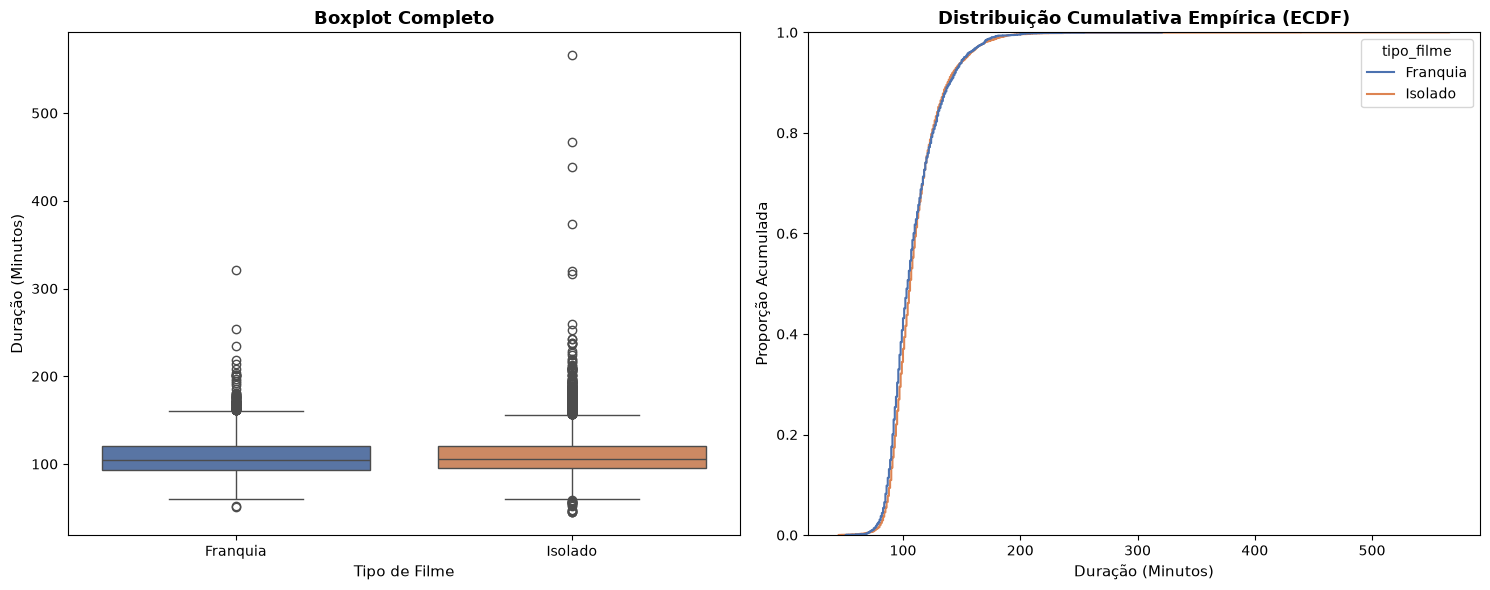

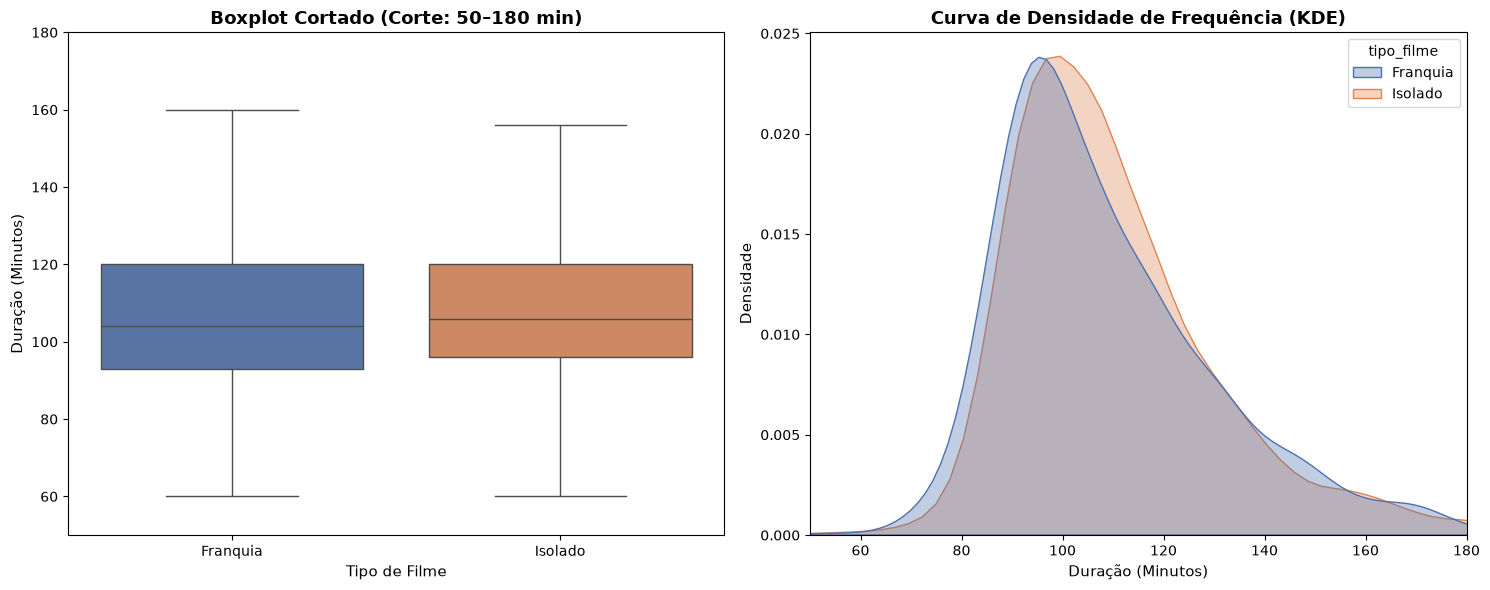

In [17]:
import pandas as pd
from scipy import stats
import os
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/df_tmdb.csv")

df_valid = df.dropna(subset=["runtimeMinutes", "is_franchise"]).copy()
df_valid["runtimeMinutes"] = df_valid["runtimeMinutes"].astype(int)
df_valid["tipo_filme"] = df_valid["is_franchise"].map({True: "Franquia", False: "Isolado"})

estatisticas = df_valid.groupby("tipo_filme")["runtimeMinutes"].agg(
    Quantidade="count",
    Média="mean",
    Mediana="median",
    Desvio_Padrão="std",
    Mínimo="min",
    Máximo="max"
).round(2)

display(estatisticas)

#teste e tamanho do efeito

franquia = df_valid[df_valid['is_franchise'] == True]['runtimeMinutes']
isolado = df_valid[df_valid['is_franchise'] == False]['runtimeMinutes']

u_stat, p_value = stats.mannwhitneyu(franquia, isolado, alternative='two-sided')

n1, n2 = len(franquia), len(isolado)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(f"N Franquia: {n1} | N Isolado: {n2}")
print(f"Mediana Franquia: {franquia.median()} min | Mediana Isolado: {isolado.median()} min")
print(f"Estatística U: {u_stat}")
print(f"p-valor (two-sided): {p_value:.7f}")
print(f"Effect size (rank-biserial r): {rank_biserial:.4f}")

if p_value < 0.05:
    if abs(rank_biserial) < 0.10:
        print("Conclusão: Há diferença estatisticamente significativa (devido ao alto N), mas o tamanho do efeito é insignificante/desprezível na prática (r < 0.10).")
    else:
        print("Conclusão: Há diferença estatisticamente e praticamente significativa.")
else:
    print("Conclusão: Não há diferença estatisticamente significativa entre os grupos.")

#visualizacao

os.makedirs('../figs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    data=df_valid,
    x='tipo_filme',
    y='runtimeMinutes',
    hue='tipo_filme',
    legend=False,
    palette=['#4C72B0', '#DD8452'],
    ax=axes[0]
)
axes[0].set_title('Boxplot Completo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tipo de Filme', fontsize=11)
axes[0].set_ylabel('Duração (Minutos)', fontsize=11)

sns.ecdfplot(
    data=df_valid,
    x='runtimeMinutes',
    hue='tipo_filme',
    palette=['#4C72B0', '#DD8452'],
    ax=axes[1]
)
axes[1].set_title('Distribuição Cumulativa Empírica (ECDF)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Duração (Minutos)', fontsize=11)
axes[1].set_ylabel('Proporção Acumulada', fontsize=11)

plt.tight_layout()
plt.savefig('../figs/h1_tecnico_completo.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    data=df_valid,
    x='tipo_filme',
    y='runtimeMinutes',
    hue='tipo_filme',
    legend=False,
    palette=['#4C72B0', '#DD8452'],
    ax=axes[0],
    showfliers=False
)
axes[0].set_title('Boxplot Cortado (Corte: 50–180 min)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tipo de Filme', fontsize=11)
axes[0].set_ylabel('Duração (Minutos)', fontsize=11)
axes[0].set_ylim(50, 180)

sns.kdeplot(
    data=df_valid,
    x='runtimeMinutes',
    hue='tipo_filme',
    common_norm=False,
    fill=True,
    alpha=0.35,
    palette=['#4C72B0', '#DD8452'],
    ax=axes[1]
)
axes[1].set_title('Curva de Densidade de Frequência (KDE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Duração (Minutos)', fontsize=11)
axes[1].set_ylabel('Densidade', fontsize=11)
axes[1].set_xlim(50, 180)

plt.tight_layout()
plt.savefig('../figs/h1_intuitivo_zoom.png', dpi=150)
plt.show()

<h3>Análise</h3>

<p>
  A crença de que <b>filmes de franquia têm durações substancialmente maiores</b> do que filmes isolados não se sustenta na prática. Os dados descritivos e os testes estatísticos demonstram que ambos os grupos compartilham uma estrutura de duração quase idêntica.
</p>

<h4>Comparação Descritiva</h4>
<p>
  Ao observar as medidas centrais, nota-se que a mediana de duração dos filmes isolados (<b>106,0 minutos</b>) é, inclusive, ligeiramente superior à dos filmes de franquia (<b>104,0 minutos</b>). A média segue a mesma tendência (<b>110,69 min</b> para isolados vs. <b>109,33 min</b> para franquias), com desvios padrão idênticos (~22,8 minutos).
</p>

<h4>Significância Estatística vs. Relevância Prática</h4>
<p>
  O teste não paramétrico de Mann-Whitney U resultou em um valor de p = 0,0000219, o que formalmente rejeita a hipótese nula de igualdade perfeita entre as distribuições. Contudo, essa significância estatística é um subproduto direto do elevado tamanho da amostra N = 12.455 produções.
</p>
<p>
  Para avaliar o impacto real, calculamos a correlação bisserial por postos <i>r</i>, que mede o tamanho do efeito:
</p>
<ul>
  <li><b>Tamanho do Efeito <i>r</i>:</b> <code>0.0540</code></li>
  <li><b>Interpretação:</b> Valores de <i>r</i> < 0,10 indicam um efeito insignificante e desprezível na prática. </li>
</ul>

<h4>Análise Visual e Distribuição</h4>
<p>
  Os gráficos confirmam esse comportamento:
</p>
<ul>
  <li><b>ECDF e Curva KDE:</b> As curvas de densidade e distribuição acumulada para ambos os grupos praticamente se sobrepõem ao longo de toda a escala, apresentando o mesmo pico central de frequência em torno dos 95–105 minutos.</li>
  <li><b>Outliers:</b> Filmes isolados apresentam valores extremos mais acentuados (máximo de 566 minutos) em comparação aos de franquia (máximo de 321 minutos), mas isso não altera a tendência central das produções comerciais.</li>
</ul>

<p>
  <b>Conclusão:</b> A hipótese de que pertencer a uma franquia implica uma duração maior é refutada. Na prática, a indústria cinematográfica adota um padrão de duração padronizado (~90 a 120 minutos) independentemente de o filme ser um título isolado ou parte de uma saga.
</p>

<h3>4.1.2 Sub-hipótese 2: O Efeito Acumulativo</h3>
<b>Pergunta:</b> À medida que uma saga progride (Filme 1, Filme 2, Filme 3+), a duração aumenta de forma contínua?

Para responder essa pergunta, foi necessário identificar a posição de cada filme dentro de sua franquia (1º, 2º, 3º...), informação obtida via API do TMDB (campo <code>belongs_to_collection</code> e a lista ordenada de <code>parts</code> de cada coleção, ordenadas por <code>release_date</code>). O resultado foi salvo em <code>df_franquias_com_posicao.csv</code>.

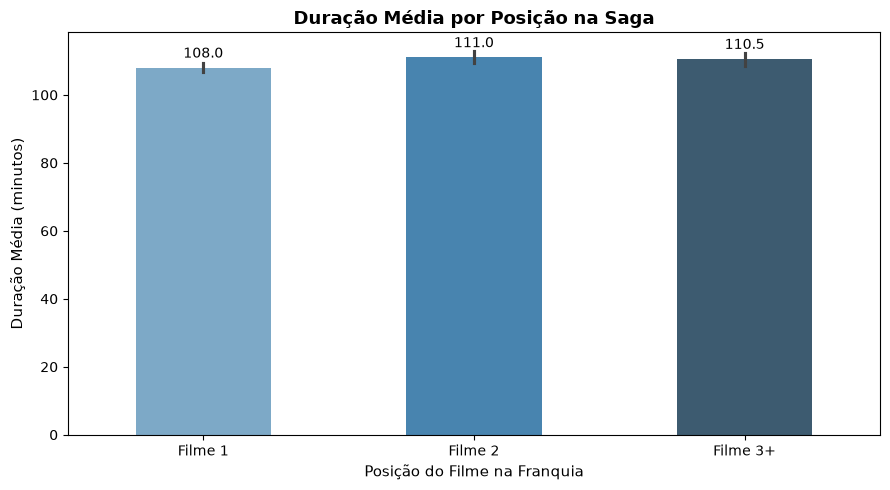

Coeficiente Angular (Slope): 0.678 min/sequência
Coeficiente de Determinação (R²): 0.0037
p-valor da Regressão: 1.84817e-03


In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

df_saga = pd.read_csv('../data/df_franquias_com_posicao.csv').dropna(
    subset=['saga_position', 'runtimeMinutes']
)
df_saga['saga_position'] = df_saga['saga_position'].astype(int)
df_saga['grupo_saga'] = df_saga['saga_position'].apply(
    lambda x: 'Filme 1' if x == 1 else ('Filme 2' if x == 2 else 'Filme 3+')
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_saga,
    x='grupo_saga',
    y='runtimeMinutes',
    order=['Filme 1', 'Filme 2', 'Filme 3+'],
    hue='grupo_saga',
    palette='Blues_d',
    legend=False,
    errorbar=('ci', 95),
    width=0.5,
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontsize=10)

plt.title('Duração Média por Posição na Saga', fontsize=13, fontweight='bold')
plt.xlabel('Posição do Filme na Franquia', fontsize=11)
plt.ylabel('Duração Média (minutos)', fontsize=11)
plt.tight_layout()
plt.savefig('../figs/h2_duracao_por_posicao_saga.png', dpi=150)
plt.show()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_saga['saga_position'], df_saga['runtimeMinutes']
)
r_squared = r_value**2
print(f'Coeficiente Angular (Slope): {slope:.3f} min/sequência')
print(f'Coeficiente de Determinação (R²): {r_squared:.4f}')
print(f'p-valor da Regressão: {p_value:.5e}')

<h4>Análise</h4>

O gráfico de barras mostra um pequeno aumento na duração média entre o primeiro filme de cada franquia (cerca de 108 minutos) e as sequências seguintes (110-111 minutos), mas a duração se estabiliza a partir do segundo filme — não há crescimento contínuo entre "Filme 2" e "Filme 3+".

<h5>Significância Estatística vs. Relevância Prática</h5>

A regressão linear confirma uma relação estatisticamente significativa entre a posição na saga e a duração (p &lt; 0.05). Contudo, o coeficiente de determinação (R² = 0.0037) mostra que a posição na saga explica menos de 1% da variação na duração dos filmes, e o coeficiente angular (~0.68 min por sequência) representa um efeito de menos de um minuto a cada novo filme lançado — irrelevante na prática.

<b>Conclusão:</b> a hipótese de crescimento contínuo de duração ao longo da saga é refutada. Embora exista uma pequena diferença entre o primeiro filme e as sequências, ela não se sustenta como tendência progressiva, e o tamanho do efeito é desprezível mesmo quando estatisticamente detectável.

<h3>4.1.3 Sub-hipótese 3: Evolução Temporal</h3>
<b>Pergunta:</b> A diferença de duração entre franquias e filmes isolados é um fenômeno recente ou sempre existiu?

Aqui investigamos se o "gap" de duração entre os dois grupos se abriu ao longo do tempo, usando uma regressão linear com termo de interação (<code>runtimeMinutes ~ startYear * is_franchise</code>), que testa formalmente se a taxa de crescimento da duração ao longo dos anos difere entre franquias e isolados.

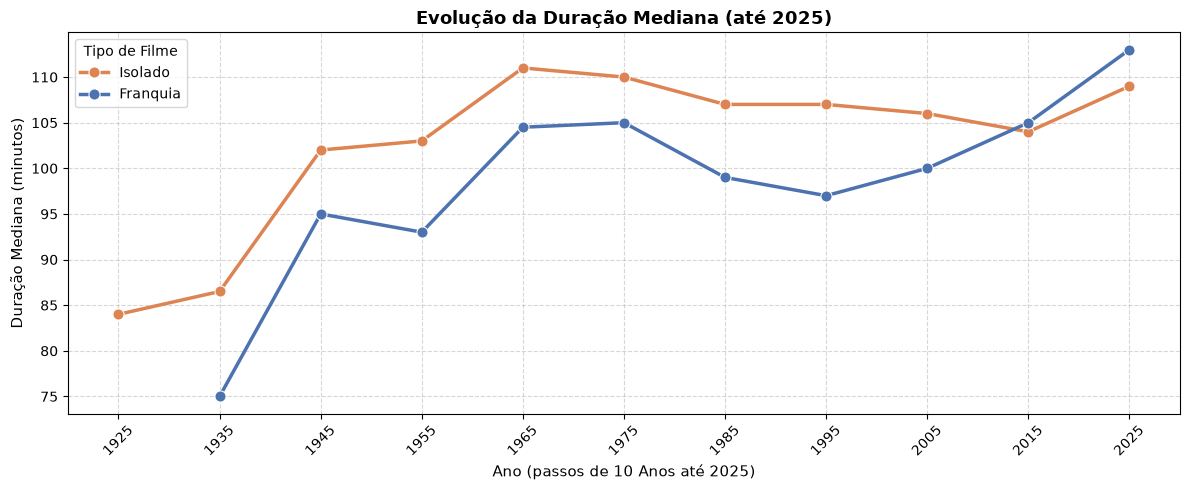

In [39]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/df_tmdb.csv")
df_clean = df.dropna(
    subset=["runtimeMinutes", "startYear", "is_franchise"]
).copy()

df_clean["startYear"] = df_clean["startYear"].astype(int)
df_clean["runtimeMinutes"] = df_clean["runtimeMinutes"].astype(int)
df_clean["tipo_filme"] = df_clean["is_franchise"].map(
    {True: "Franquia", False: "Isolado"}
)

df_clean = df_clean[
    (df_clean["startYear"] > 1915) & (df_clean["startYear"] <= 2025)
].copy()

bins = list(range(1915, 2035, 10))
labels = list(range(1925, 2035, 10))

df_clean["ano_ancora"] = pd.cut(
    df_clean["startYear"], bins=bins, labels=labels, right=True
)

df_clean = df_clean.dropna(subset=["ano_ancora"]).copy()
df_clean["ano_ancora"] = df_clean["ano_ancora"].astype(int)
df_clean = df_clean[df_clean["ano_ancora"] <= 2025]

mediana_ancorada = (
    df_clean.groupby(["ano_ancora", "tipo_filme"], observed=False)[
        "runtimeMinutes"
    ]
    .median()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=mediana_ancorada,
    x="ano_ancora",
    y="runtimeMinutes",
    hue="tipo_filme",
    marker="o",
    markersize=8,
    linewidth=2.5,
    palette=["#DD8452", "#4C72B0"],
)

plt.title(
    "Evolução da Duração Mediana (até 2025)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Ano (passos de 10 Anos até 2025)", fontsize=11)
plt.ylabel("Duração Mediana (minutos)", fontsize=11)

anos_marcadores = sorted(mediana_ancorada["ano_ancora"].unique())
plt.xticks(anos_marcadores, rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Tipo de Filme")
plt.tight_layout()

os.makedirs("../figs", exist_ok=True)
plt.savefig("../figs/h3_evolucao_ancorada_2025.png", dpi=150)
plt.show()

In [40]:
print(df_clean.groupby('ano_ancora', observed=False)['tipo_filme'].value_counts())

ano_ancora  tipo_filme
1925        Isolado         18
1935        Isolado         52
            Franquia         9
1945        Isolado        125
            Franquia        13
1955        Isolado        207
            Franquia        15
1965        Isolado        267
            Franquia        42
1975        Isolado        331
            Franquia        84
1985        Isolado        474
            Franquia       203
1995        Isolado        926
            Franquia       348
2005        Isolado       1671
            Franquia       475
2015        Isolado       2778
            Franquia       706
2025        Isolado       2943
            Franquia       690
Name: count, dtype: int64


<p><i>Nota: a mediana geral reportada na Sub-hipótese 1 (106 vs. 104 min) é dominada pelas décadas mais 
recentes, que concentram a maior parte das observações do dataset. O gráfico acima, ao tratar cada 
década com peso igual, revela um padrão histórico que a mediana agregada da H1 esconde.</i></p>

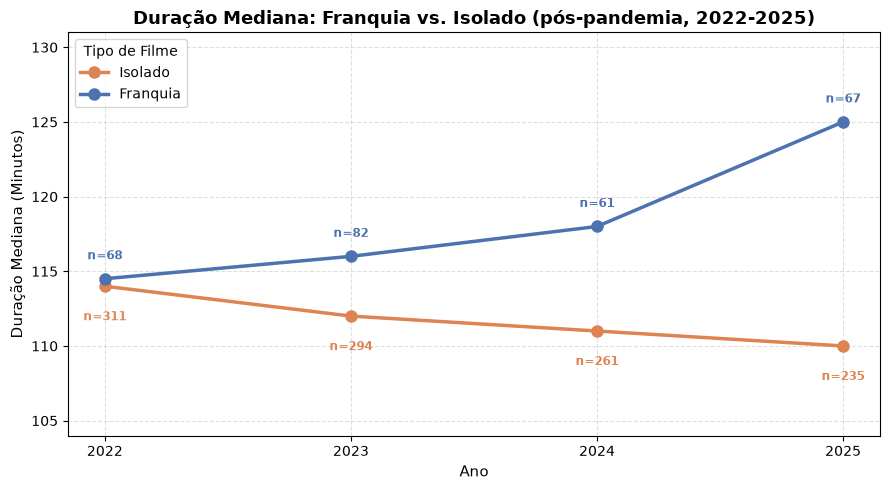

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/df_tmdb.csv')
df_clean = df.dropna(subset=['runtimeMinutes', 'startYear', 'is_franchise']).copy()
df_clean['startYear'] = df_clean['startYear'].astype(int)
df_clean['runtimeMinutes'] = df_clean['runtimeMinutes'].astype(int)
df_clean['tipo_filme'] = df_clean['is_franchise'].map({True: 'Franquia', False: 'Isolado'})

df_pos_pandemia = df_clean[
    (df_clean['startYear'] >= 2022) & (df_clean['startYear'] <= 2025)
].copy()

mediana_ano = (
    df_pos_pandemia.groupby(['startYear', 'tipo_filme'])['runtimeMinutes']
    .agg(['median', 'count'])
    .reset_index()
)

plt.figure(figsize=(9, 5))
cores = {'Isolado': '#DD8452', 'Franquia': '#4C72B0'}
offsets = {'Isolado': -18, 'Franquia': 12}
va = {'Isolado': 'top', 'Franquia': 'bottom'}

for tipo in ['Isolado', 'Franquia']:
    sub = mediana_ano[mediana_ano['tipo_filme'] == tipo]
    plt.plot(sub['startYear'], sub['median'], marker='o', markersize=8,
              linewidth=2.5, label=tipo, color=cores[tipo])
    for _, row in sub.iterrows():
        plt.annotate(f"n={int(row['count'])}", (row['startYear'], row['median']),
                     textcoords="offset points", xytext=(0, offsets[tipo]),
                     ha='center', va=va[tipo], fontsize=8.5, color=cores[tipo],
                     fontweight='bold')

plt.title('Duração Mediana: Franquia vs. Isolado (pós-pandemia, 2022-2025)',
          fontsize=13, fontweight='bold')
plt.xlabel('Ano', fontsize=11)
plt.ylabel('Duração Mediana (Minutos)', fontsize=11)
plt.xticks(sorted(df_pos_pandemia['startYear'].unique()))

ymin = mediana_ano['median'].min() - 6
ymax = mediana_ano['median'].max() + 6
plt.ylim(ymin, ymax)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Tipo de Filme')
plt.tight_layout()
plt.savefig('../figs/h3_pos_pandemia.png', dpi=150)
plt.show()

In [42]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv('../data/df_tmdb.csv')
df_clean = df.dropna(subset=['runtimeMinutes', 'startYear', 'is_franchise']).copy()
df_clean['startYear'] = df_clean['startYear'].astype(int)
df_clean['runtimeMinutes'] = df_clean['runtimeMinutes'].astype(int)
df_clean['tipo_filme'] = df_clean['is_franchise'].map({True: 'Franquia', False: 'Isolado'})
df_clean['is_franchise_num'] = df_clean['is_franchise'].astype(int)
df_clean['startYear_c'] = df_clean['startYear'] - 2022
df_clean['era_recente'] = (df_clean['startYear'] >= 2022).astype(int)

modelo_era = smf.ols(
    'runtimeMinutes ~ startYear_c * is_franchise_num + is_franchise_num * era_recente',
    data=df_clean
).fit()

coef_era = modelo_era.params['is_franchise_num:era_recente']
p_era = modelo_era.pvalues['is_franchise_num:era_recente']
print(modelo_era.summary())
print(f'\nEfeito extra de ser franquia na era recente (2022+): {coef_era:.2f} min (p={p_era:.4f})')

                            OLS Regression Results                            
Dep. Variable:         runtimeMinutes   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     60.84
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           7.59e-63
Time:                        16:48:01   Log-Likelihood:                -56536.
No. Observations:               12455   AIC:                         1.131e+05
Df Residuals:                   12449   BIC:                         1.131e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

<h4>Análise</h4>

<p>O gráfico ancorado em 2025 mostra que, ao longo da maior parte do século, filmes isolados tiveram 
duração mediana igual ou superior à de franquias — só nas últimas duas décadas essa relação se inverte, 
com franquias ultrapassando isolados de forma visível.</p>

<p>Para testar se essa mudança recente é estatisticamente robusta, o corte foi definido por um critério 
substantivo — pós-pandemia (2022), quando os cinemas voltaram à normalidade — e testado com a base 
completa (12.455 filmes), não apenas a fatia recente. A centralização de <code>startYear</code> em torno 
de 2022 resolveu o problema de multicolinearidade identificado anteriormente: o número de condição caiu 
de 6,55e+05 para 245, e os coeficientes passaram a ser interpretáveis individualmente.</p>

<h5>Resultado do modelo</h5>

<p>O modelo confirma o padrão observado visualmente:</p>

<ul>
<li><b>Tendência histórica (<code>startYear_c:is_franchise_num</code>)</b>: 0,21 min/ano extras para 
franquias, estatisticamente significativo (p &lt; 0,001), mas pequeno em magnitude ao longo de décadas.</li>
<li><b>Efeito da era recente (<code>is_franchise_num:era_recente</code>)</b>: <b>5,61 minutos extras</b> 
para franquias especificamente a partir de 2022, além do que já era esperado pela tendência histórica 
(p = 0,0012, IC 95% [2,22, 8,99]). Essa diferença de magnitude é bem maior que o efeito acumulado ao 
longo de décadas..</li>
</ul>

<h5>Significância Estatística vs. Relevância Prática</h5>

<p>Diferente do padrão "significativo mas irrisório" que apareceu nas outras sub-hipóteses, aqui o efeito 
é significativo <i>e</i> perceptível na prática: quase 6 minutos a mais por sessão de cinema é uma 
diferença que o público notaria. Vale notar que o termo <code>startYear_c</code> isolado não é 
significativo (p = 0,950) — isso é esperado, já que ele representa a tendência para filmes isolados 
apenas, e não há razão para esperar que a duração de filmes isolados tenha mudado sistematicamente ano 
a ano fora do efeito de franquia.</p>

<b>Conclusão:</b> ao contrário das Sub-hipóteses 1 e 2, aqui há evidência de uma mudança estrutural 
real e recente: franquias passaram a ter, na era pós-pandemia, duração significativamente maior do que 
a tendência histórica projetaria — um fenômeno que não existia (e por boa parte do século foi até 
invertido) nas décadas anteriores.

<h4>Análise de Robustez: Sequências (Filme 2+) vs. Isolados Puros</h4>
<p>
Para testar a estabilidade dos achados da Sub-hipótese 1 e eliminar o risco de um viés de diluição provocado pelo primeiro filme de cada saga (que frequentemente é concebido como obra isolada e sem garantia de continuidade), realizamos um <b>teste de sensibilidade</b> comparando exclusivamente <i>Sequências Consolidadas</i> (posição na saga &ge; 2) contra <i>Isolados Puros</i> (obras que jamais geraram franquias).
</p>

In [43]:
import pandas as pd
from scipy import stats

df_main = pd.read_csv('../data/df_tmdb.csv')
df_saga = pd.read_csv('../data/df_franquias_com_posicao.csv')

sequencias = df_saga[df_saga['saga_position'] >= 2]['runtimeMinutes'].dropna()

isolados_puros = df_main[df_main['is_franchise'] == False][
    'runtimeMinutes'
].dropna()

# Teste de Mann-Whitney U
u_stat, p_value = stats.mannwhitneyu(
    sequencias, isolados_puros, alternative='two-sided'
)
n1, n2 = len(sequencias), len(isolados_puros)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(
    '=== ANÁLISE DE ROBUSTEZ (H1): SEQUÊNCIAS (FILME 2+) VS. ISOLADOS PUROS ==='
)
print(f'N Sequências (Filme 2+): {n1} | Mediana: {sequencias.median():.1f} min')
print(f'N Isolados Puros: {n2} | Mediana: {isolados_puros.median():.1f} min')
print(f'p-valor: {p_value:.5e}')
print(f'Tamanho do Efeito (Rank-Biserial r): {rank_biserial:.4f}')

if abs(rank_biserial) < 0.10:
  print(
      '\nConclusão da Robustez: Mesmo isolando apenas sequências puras (Filme'
      ' 2+), o efeito prático continua insignificante (r < 0.10). A'
      ' conclusão da H1 principal é mantida com alta estabilidade.'
  )
else:
  print(
      '\nConclusão da Robustez: O tamanho do efeito aumentou! A exclusão do'
      ' "Filme 1" revela que as sequências de fato possuem duração superior'
      ' em relação aos filmes isolados.'
  )

=== ANÁLISE DE ROBUSTEZ (H1): SEQUÊNCIAS (FILME 2+) VS. ISOLADOS PUROS ===
N Sequências (Filme 2+): 1251 | Mediana: 106.0 min
N Isolados Puros: 9850 | Mediana: 106.0 min
p-valor: 7.14632e-01
Tamanho do Efeito (Rank-Biserial r): 0.0063

Conclusão da Robustez: Mesmo isolando apenas sequências puras (Filme 2+), o efeito prático continua insignificante (r < 0.10). A conclusão da H1 principal é mantida com alta estabilidade.


<h4>Resultados do Teste de Sensibilidade</h4>
<p>
Ao isolar o efeito das continuações, nota-se uma equivalência exata nas medidas de tendência central:
</p>
<ul>
<li><b>Sequências Consolidadas (Filme 2+):</b> <code>N = 1.251</code> | Mediana de <b>106,0 minutos</b></li>
<li><b>Isolados Puros:</b> <code>N = 9.850</code> | Mediana de <b>106,0 minutos</b></li>
</ul>

<h4>Significância Estatística e Tamanho do Efeito</h4>
<p>
O teste não paramétrico de Mann-Whitney U e a métrica de tamanho de efeito confirmam a estabilidade do resultado:
</p>
<ul>
<li><b>p-valor:</b> <code>0,7146</code> (confirma formalmente a ausência de diferença estatística entre os grupos)</li>
<li><b>Tamanho do Efeito (<i>r</i> de Rank-Biserial):</b> <code>0,0063</code></li>
<li><b>Interpretação:</b> Valores de <i>r</i> &lt; 0,10 indicam um efeito irrelevante na prática. O fato de ambas as medianas serem idênticas (106,0 min) prova que o "Filme 1" não estava diluindo nenhum efeito oculto na H1 principal.</li>
</ul>

<p>
<b>Conclusão da Robustez:</b> A hipótese de que pertencer a uma franquia exige mais tempo do público continua refutada com alto grau de estabilidade. Mesmo ao analisar isoladamente as continuações já consolidadas, o padrão de duração da indústria permanece perfeitamente alinhado ao dos filmes isolados.
</p>

4.2 AQUIIIIIIIIII

4.3 AQUIIIIIIIIIIIIIII

4.4 AQUIIIIIIIIIIIIIII

<h3>4.5 A divergência entre crítica e público é maior em algum gênero específico?</h3>

<h3>🎯 Motivação</h3>

Existe um debate clássico na indústria do entretenimento sobre o abismo entre o que a crítica especializada considera "bom" (foco em arte, roteiro, inovação) e o que o público geral gosta de consumir (foco em entretenimento, ritmo, diversão). Esta análise busca quantificar esse abismo na era do cinema moderno.

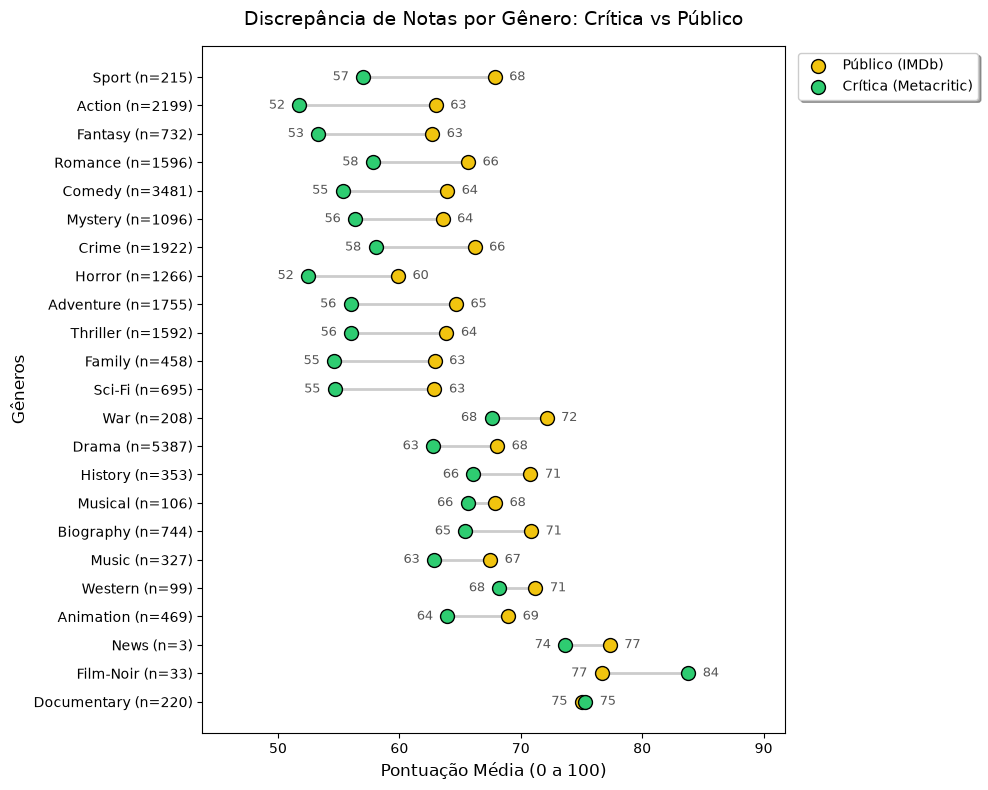

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/df_omdb.csv')

# filtrar apenas filmes que possuem nota da crítica (ignorar nulos e -1)
df_validos = df[(df['metascore_critica'].notna()) & (df['metascore_critica'] > 0)].copy()

# nivelar a escala do IMDb (0 a 10) para a escala do Metacritic (0 a 100)
df_validos['imdb_norm'] = df_validos['averageRating'] * 10

# calcular a divergência:
df_validos['divergencia_direcional'] = df_validos['metascore_critica'] - df_validos['imdb_norm']
df_validos['divergencia_absoluta'] = df_validos['divergencia_direcional'].abs()

# cada filme é classificado de 1 a 3 gêneros. Mas para a análise, separamos os gêneros individualmente
df_validos['genero_lista'] = df_validos['genres'].astype(str).str.split(',')
df_exploded = df_validos.explode('genero_lista')
df_exploded = df_exploded[df_exploded['genero_lista'] != '\\N']

generos = df_exploded.groupby('genero_lista').agg({
    'imdb_norm': 'mean',
    'metascore_critica': 'mean',
    'divergencia_direcional': 'mean',
    'divergencia_absoluta': 'mean',
    'tconst': 'count'
}).reset_index()

generos = generos.rename(columns={'tconst': 'n_filmes'})
generos['genero'] = generos['genero_lista'] + ' (n=' + generos['n_filmes'].astype(str) + ')'

# gráfico 
genero_div_abs = generos.sort_values('divergencia_absoluta', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

ax.hlines(y=genero_div_abs['genero'],
          xmin=genero_div_abs['imdb_norm'],
          xmax=genero_div_abs['metascore_critica'],
          color='grey', alpha=0.4, linewidth=2, zorder=1)

ax.scatter(genero_div_abs['imdb_norm'], genero_div_abs['genero'],
           color='#f1c40f', s=100, label='Público (IMDb)', zorder=2, edgecolors='black')
ax.scatter(genero_div_abs['metascore_critica'], genero_div_abs['genero'],
           color='#2ecc71', s=100, label='Crítica (Metacritic)', zorder=2, edgecolors='black')

for _, row in genero_div_abs.iterrows():
    esquerda = min(row['imdb_norm'], row['metascore_critica'])
    direita = max(row['imdb_norm'], row['metascore_critica'])
    ax.text(esquerda - 1.2, row['genero'], f"{esquerda:.0f}", va='center', ha='right', fontsize=9, color='#555555')
    ax.text(direita + 1.2, row['genero'], f"{direita:.0f}", va='center', ha='left', fontsize=9, color='#555555')

ax.set_title('Discrepância de Notas por Gênero: Crítica vs Público', fontsize=14, pad=15)
ax.set_xlabel('Pontuação Média (0 a 100)', fontsize=12)
ax.set_ylabel('Gêneros', fontsize=12)

ax.set_xlim(genero_div_abs[['imdb_norm', 'metascore_critica']].min().min() - 8,
            genero_div_abs[['imdb_norm', 'metascore_critica']].max().max() + 8)

ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True, shadow=True)

plt.tight_layout()
plt.show()

<h4>Análise</h4>

Em quase a totalidade dos gêneros analisados, o público avaliou os filmes com notas superiores às da crítica.

O tamanho da divergência separa claramente o cinema em dois grupos. Obras de entretenimento de massa (como Action, Sport, Fantasy, Comedy e Adventure) apresentam enormes abismos de opinião, com o público dando de 8 a 11 pontos de vantagem em relação à avaliação da crítica. Em contrapartida, gêneros de cunho mais sério ou informativo (como War, Drama, History, Biography e Animation) mostram divergências mínimas de, no máximo, 6 pontos. Destaca-se o gênero Documentary, que representa um caso raro de convergência e empate técnico quase perfeito entre as duas pontas (75 pontos).

O achado mais interessante, no entanto, reside no gênero Film-Noir. Ele desponta como a única exceção de toda a base em que a crítica avaliou os filmes com notas superiores às do público (expressivos 84 pontos no Metacritic contra 77 no IMDb). Por ser um gênero clássico, denso e marcado por forte estética visual e roteiros cínicos, o Noir exige uma bagagem cinematográfica que atrai a reverência da academia, enquanto o público geral de hoje pode considerá-lo de difícil digestão.

Conclusão: Os dados reforçam o padrão da indústria cinematográfica. A crítica e o público convergem (ou invertem a balança a favor da crítica, como no Film-Noir) quando a obra carrega forte ambição artística ou histórica. Por outro lado, eles divergem fortemente nas produções de cinema comercial, que priorizam fórmulas consagradas de bilheteria e cumprem seu papel de agradar o público geral, sem necessariamente conquistar o reconhecimento técnico da crítica especializada.